<a href="https://colab.research.google.com/github/pach28/Predict-Podcast-Listening-Time/blob/main/NaN_Test_Imputation_Promedio_y_Ensemble_por_Combinacion_PPLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

pt1

#instalamos librerias necesarias e iniciamos sesion de kaggle para acceder a la data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_style('whitegrid')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install dabl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 7.3 MB/s eta 0:00:00


In [ ]:
import dabl

In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
import os

# Download the competition dataset
playground_series_s5e4_path = kagglehub.competition_download('playground-series-s5e4')
# Extract the directory name from the downloaded path
dataset_dir = os.path.splitext(playground_series_s5e4_path)[0]

# Construct the correct paths to the train.csv and test.csv files
train_csv_path = os.path.join(dataset_dir, 'train.csv')
test_csv_path = os.path.join(dataset_dir, 'test.csv')
sample_submission_csv_path = os.path.join(dataset_dir, 'sample_submission.csv')
# Read the CSV files using the correct paths
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
sample_submission_df = pd.read_csv(sample_submission_csv_path)

100%|██████████| 22.3M/22.3M [00:01<00:00, 14.1MB/s]

Extracting files...


In [ ]:
#datos extra
dataset_name = "ysthehurricane/podcast-listening-time-prediction-dataset"
extra = os.path.splitext(kagglehub.dataset_download(dataset_name))[0]
train_extra_path = os.path.join(extra, 'podcast_dataset.csv')
train_extra_df = pd.read_csv(train_extra_path)

100%|██████████| 1.15M/1.15M [00:00<00:00, 1.41MB/s]

Extracting files...


In [ ]:
train_extra_df.head()

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Healthy Living,Episode 77,99.25,Health,21.37,Thursday,Night,70.22,3,Positive,55.158695
1,Mystery Matters,Episode 6,19.43,True Crime,47.19,Friday,Evening,75.15,1,Neutral,7.686559
2,Current Affairs,Episode 1,117.03,News,96.33,Sunday,Night,57.95,3,Neutral,110.064645
3,Mystery Matters,Episode 38,16.97,True Crime,25.73,Monday,Night,24.19,0,Positive,12.000380
4,Humor Hub,Episode 73,83.48,Comedy,76.69,Tuesday,Afternoon,42.31,3,Positive,NaN


In [ ]:
train_df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


#EDA

In [ ]:
#quitamos el NaN de Number_of_Ads
train_df = train_df.dropna(subset=['Number_of_Ads'])

antes de tratar los outliers tratamos los NaN

In [ ]:
train_df['Episode_Length_minutes'].max()

325.24

In [ ]:
train_df['Listening_Time_minutes'].max()

119.97

In [ ]:
test_df['Episode_Length_minutes'].max()

78486264.0

In [ ]:
#encontrar y corregir esos maxs
#identificar el id del max en train
id_max_train = train_df['Episode_Length_minutes'].idxmax()
id_max_test = test_df['Episode_Length_minutes'].idxmax()
train_df.at[id_max_train, 'Episode_Length_minutes'] = train_df[(train_df['Podcast_Name'] == train_df.loc[id_max_train,'Podcast_Name']) & (train_df['Episode_Title'] == train_df.loc[id_max_train,'Episode_Title']) & (train_df['Episode_Length_minutes'].notnull())]['Episode_Length_minutes'].mean()
test_df.at[id_max_test, 'Episode_Length_minutes'] = train_df[(train_df['Podcast_Name'] == train_df.loc[id_max_test,'Podcast_Name']) & (train_df['Episode_Title'] == train_df.loc[id_max_test,'Episode_Title']) & (train_df['Episode_Length_minutes'].notnull())]['Episode_Length_minutes'].mean()

In [ ]:
test_df['Episode_Length_minutes'].max()

7575.0

In [ ]:
id_max_test_2 = test_df['Episode_Length_minutes'].idxmax()
test_df.at[id_max_test_2, 'Episode_Length_minutes'] = train_df[(train_df['Podcast_Name'] == train_df.loc[id_max_test_2,'Podcast_Name']) & (train_df['Episode_Title'] == train_df.loc[id_max_test_2,'Episode_Title']) & (train_df['Episode_Length_minutes'].notnull())]['Episode_Length_minutes'].mean()

In [ ]:
test_df['Episode_Length_minutes'].max()

120.73

In [ ]:
train_df.isna().sum()

,0
id,0
Podcast_Name,0
Episode_Title,0
Episode_Length_minutes,87093
Genre,0
Host_Popularity_percentage,0
Publication_Day,0
Publication_Time,0
Guest_Popularity_percentage,146030
Number_of_Ads,0


en esta ocasion no trataremos los nan de train

In [ ]:
#train quitando los nan de episode length
train_df_nan = train_df.dropna(subset=['Episode_Length_minutes'])

Target looks like regression


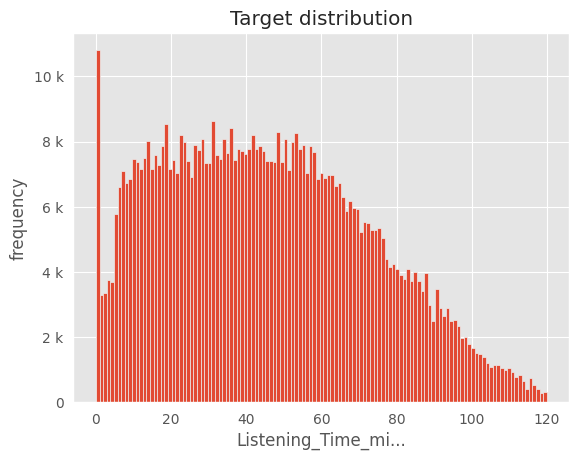

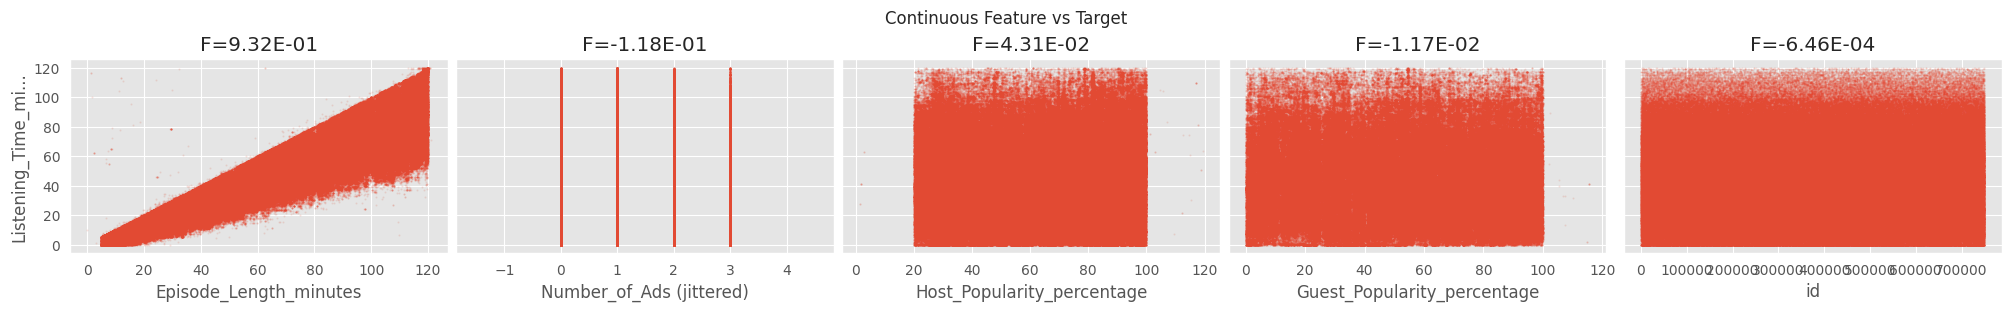

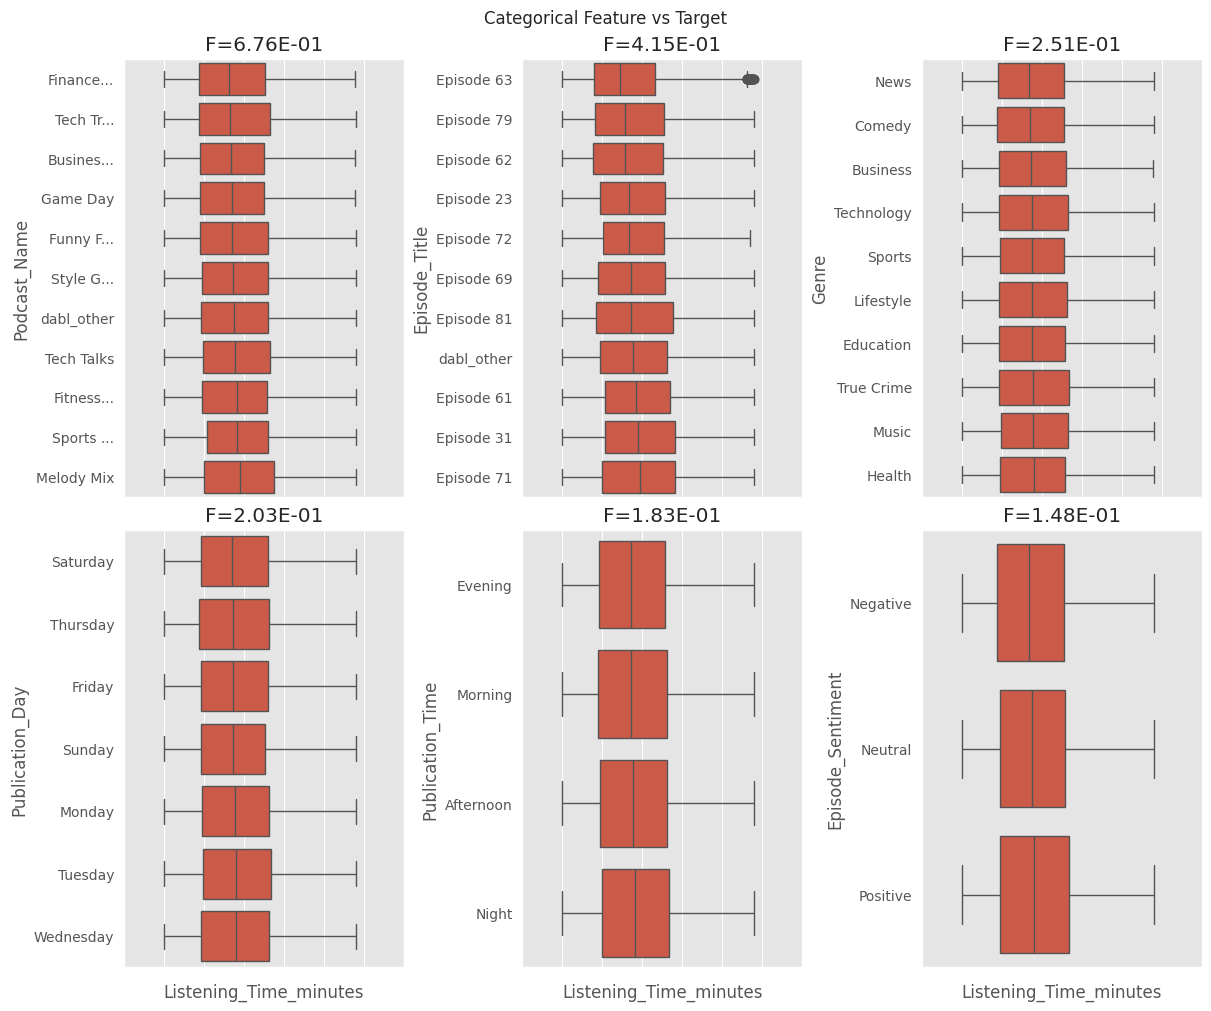

In [ ]:
import dabl
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
dabl.plot(train_df_nan, target_col = 'Listening_Time_minutes')
# Acceder a la figura y los ejes
fig, ax = plt.gcf(), plt.gca()

# Eliminar la cuadrícula
ax.grid(False)

# Mostrar el gráfico
plt.show()

Target looks like regression


[<Axes: title={'center': 'Target distribution'}, xlabel='Listening_Time_mi...', ylabel='frequency'>,
 array([[<Axes: title={'center': 'F=4.04E-01'}, xlabel='Episode_Length_minutes', ylabel='Listening_Time_mi...'>,
         <Axes: title={'center': 'F=1.47E-01'}, xlabel='Guest_Popularity_percentage'>,
         <Axes: title={'center': 'F=-6.87E-02'}, xlabel='Host_Popularity_percentage'>,
         <Axes: title={'center': 'F=2.36E-04'}, xlabel='id'>]],
       dtype=object),
 array([[<Axes: title={'center': 'F=2.15E-01'}, xlabel='Listening_Time_minutes', ylabel='Podcast_Name'>,
         <Axes: title={'center': 'F=9.50E-02'}, xlabel='Listening_Time_minutes', ylabel='Episode_Title'>,
         <Axes: title={'center': 'F=8.69E-02'}, xlabel='Listening_Time_minutes', ylabel='Genre'>,
         <Axes: title={'center': 'F=7.45E-02'}, xlabel='Listening_Time_minutes', ylabel='Publication_Day'>],
        [<Axes: title={'center': 'F=6.21E-02'}, xlabel='Listening_Time_minutes', ylabel='Publication_Time'>,

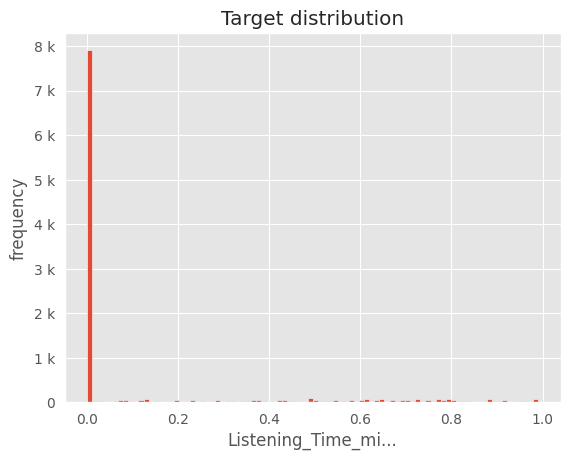

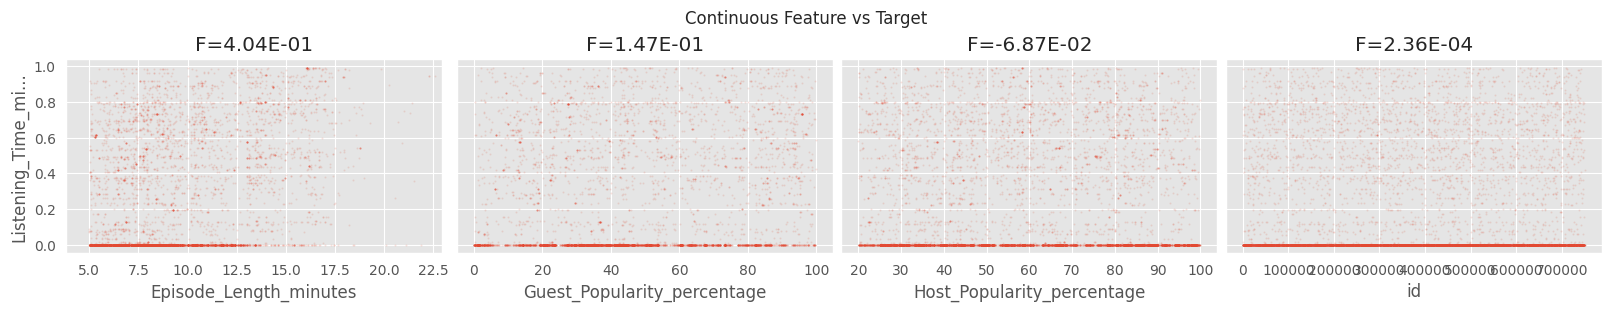

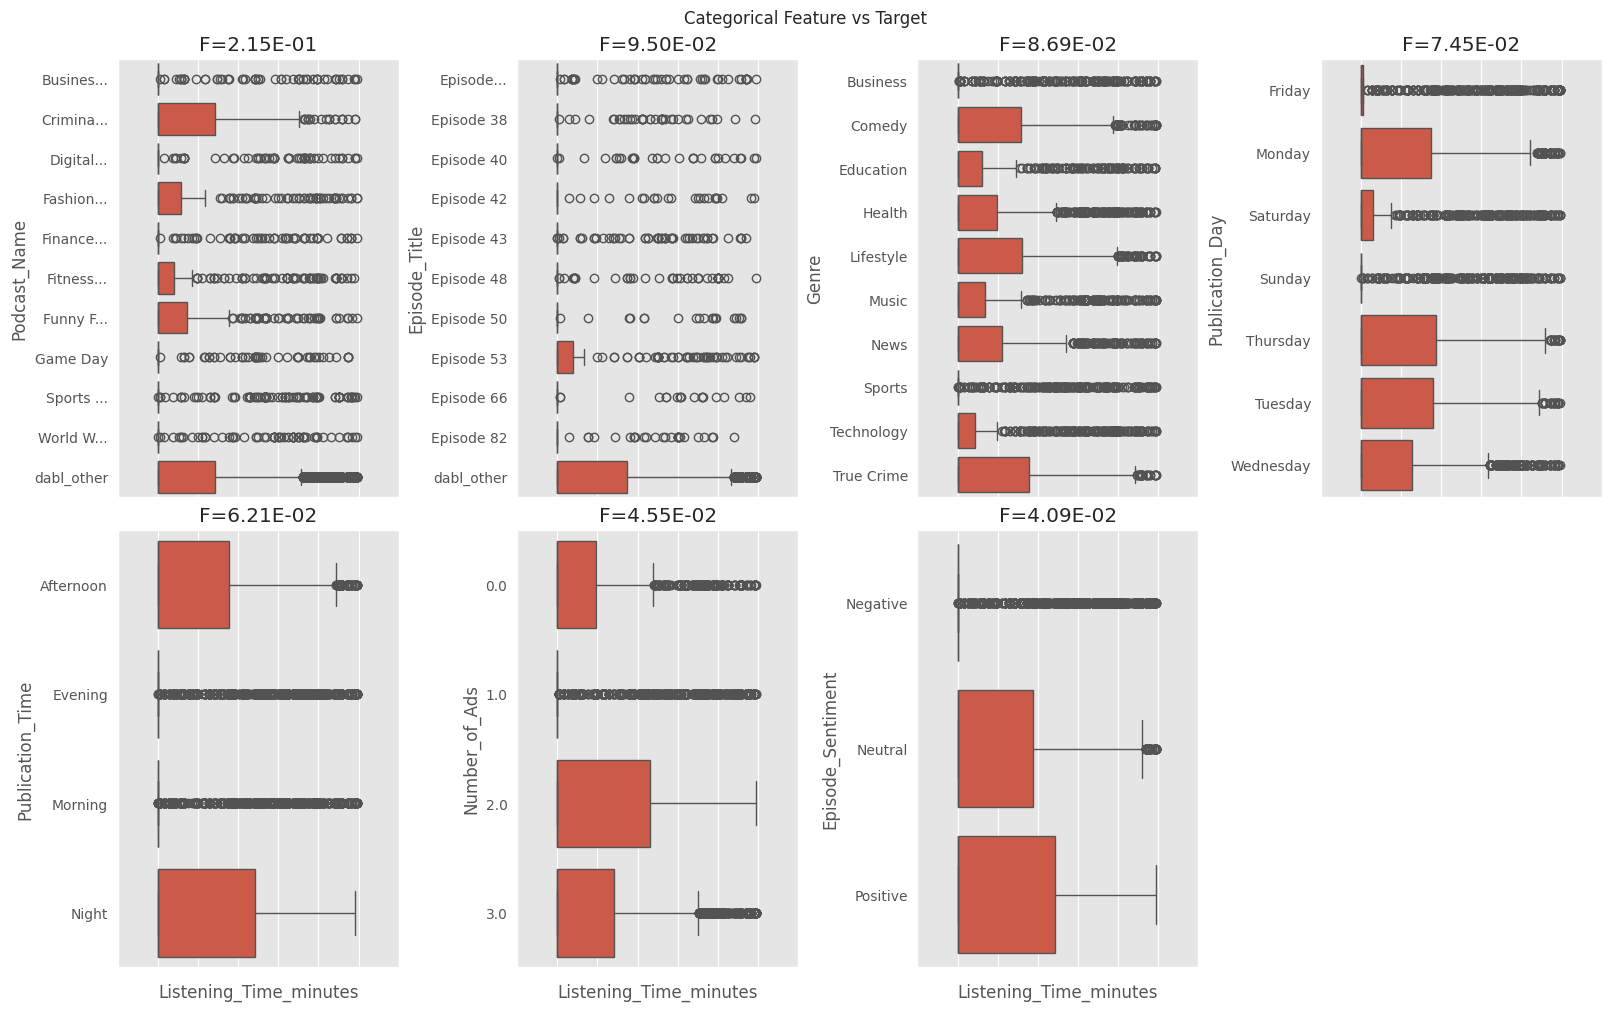

In [ ]:
#hacer dabl pero solo en los episodios escuchados menor que 1
dabl.plot(train_df_nan[train_df_nan['Listening_Time_minutes'] < 1], target_col = 'Listening_Time_minutes')

In [ ]:
train_df_nan_sin_ceros = train_df_nan[train_df_nan['Listening_Time_minutes'] > 1]

In [ ]:
test_df['Number_of_Ads'].idxmax()

178393

In [ ]:
id_max_test_ads = test_df['Number_of_Ads'].idxmax()
test_df.at[id_max_test_ads, 'Number_of_Ads'] = round(train_df[(train_df['Podcast_Name'] == train_df.loc[id_max_test_ads,'Podcast_Name']) & (train_df['Episode_Title'] == train_df.loc[id_max_test_ads,'Episode_Title'])]['Number_of_Ads'].mean())

In [ ]:
id_max_test_ads = test_df['Number_of_Ads'].idxmax()
test_df.at[id_max_test_ads, 'Number_of_Ads'] = round(train_df[(train_df['Podcast_Name'] == train_df.loc[id_max_test_ads,'Podcast_Name']) & (train_df['Episode_Title'] == train_df.loc[id_max_test_ads,'Episode_Title'])]['Number_of_Ads'].mean())

In [ ]:
train_df_copy_2 = train_df_nan_sin_ceros
train_df_copy_2 = train_df_copy_2[train_df_copy_2['Episode_Length_minutes'] > train_df_copy_2['Listening_Time_minutes']]
train_df_copy_2 = train_df_copy_2[train_df_copy_2['Number_of_Ads'] < 12]

Target looks like regression


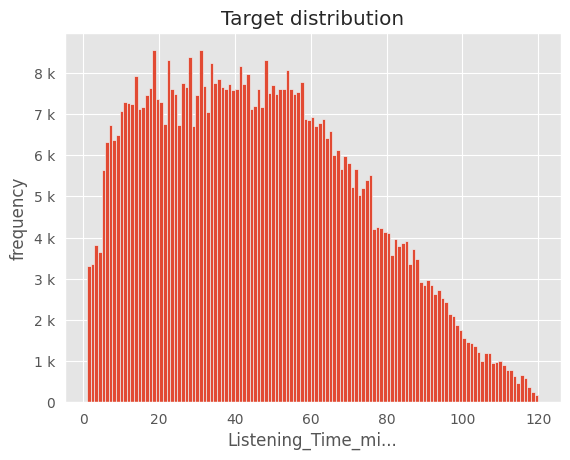

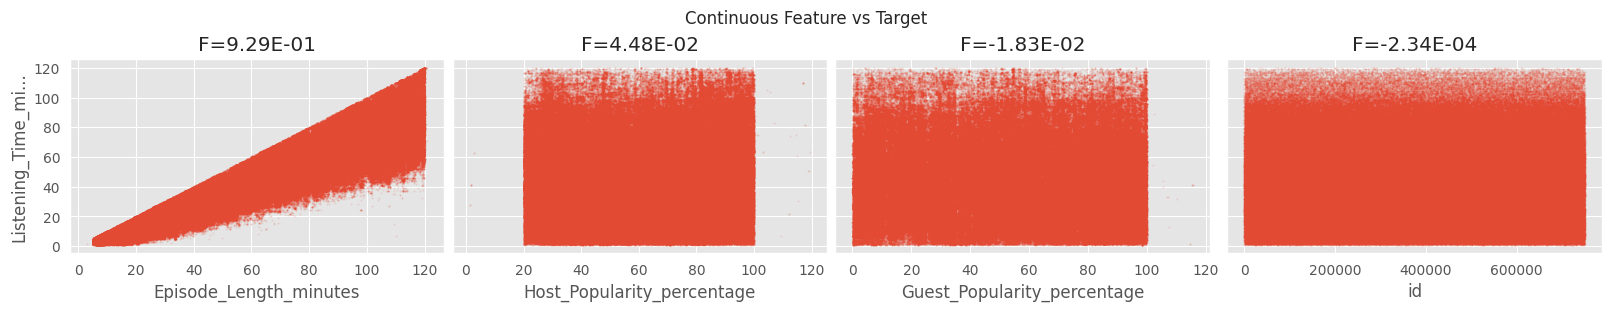

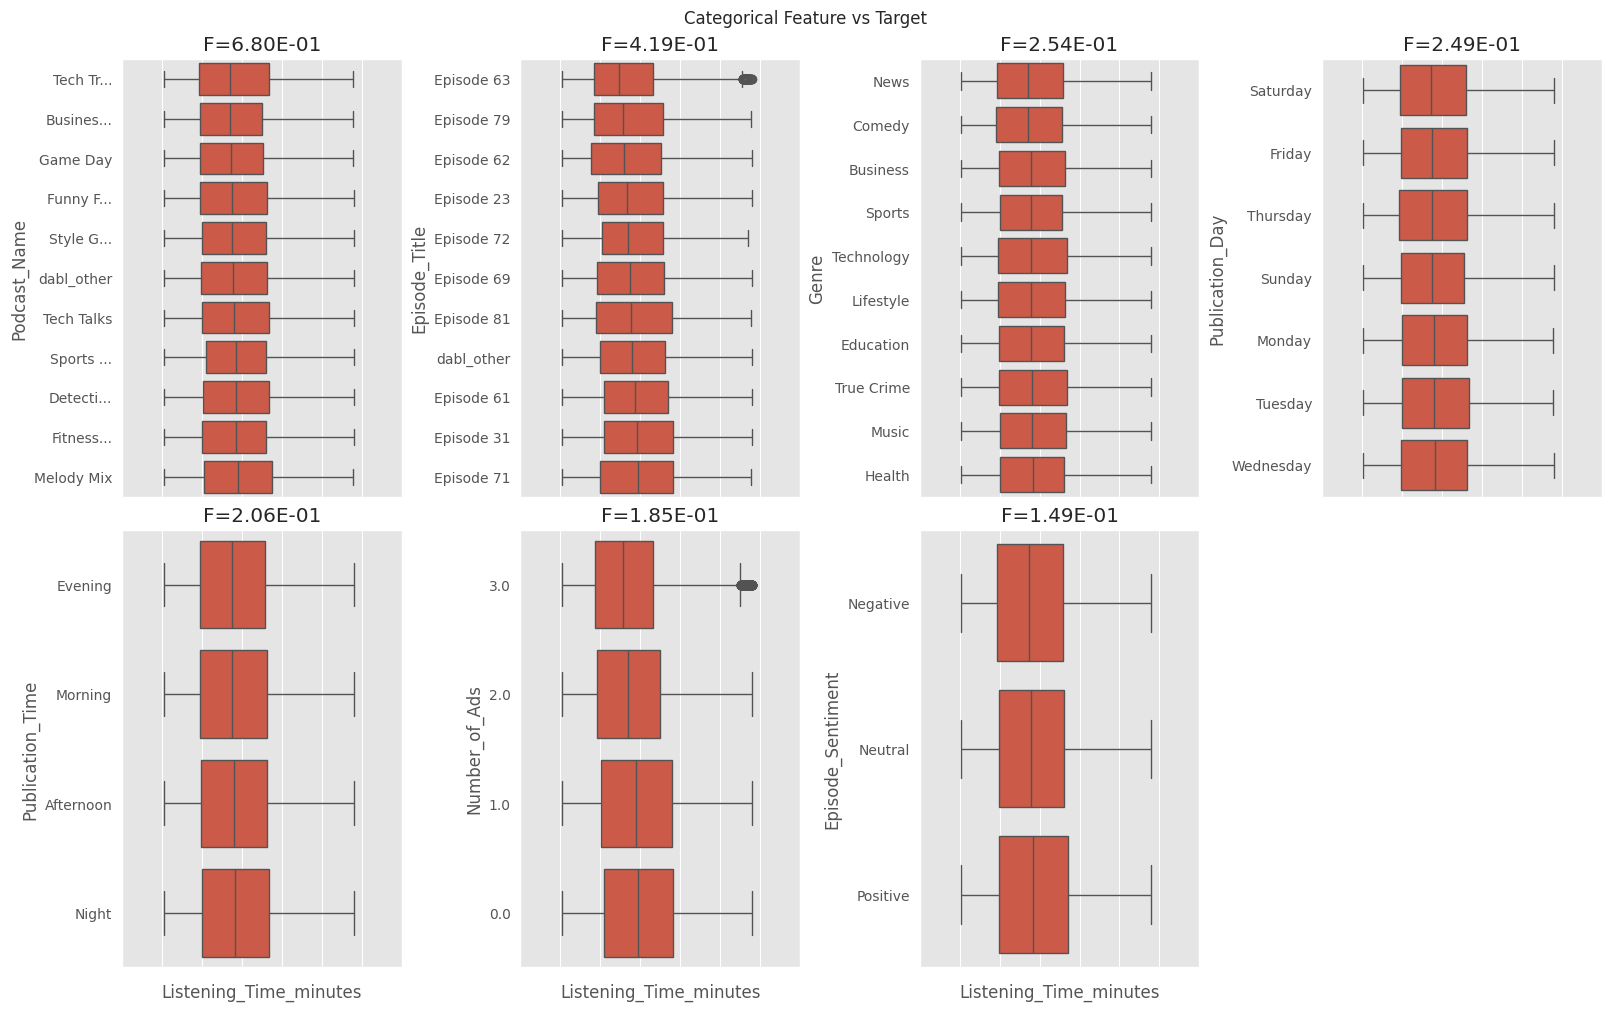

In [ ]:
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
dabl.plot(train_df_copy_2, target_col = 'Listening_Time_minutes')
# Acceder a la figura y los ejes
fig, ax = plt.gcf(), plt.gca()

# Eliminar la cuadrícula
ax.grid(False)

# Mostrar el gráfico
plt.show()

In [ ]:
#ratio total de listening y episode length
train_df_copy_2['Listening_Time_minutes'].sum() / train_df_copy_2['Episode_Length_minutes'].sum()

np.float64(0.7093109150537574)

In [ ]:
import xgboost as xgb
# Modelos de regresión lineal
from sklearn.linear_model import LinearRegression

# Modelos basados en árboles
from sklearn.ensemble import RandomForestRegressor

# Modelos Gradient Boosting
import lightgbm as lgb
# Funciones de evaluación
from sklearn.metrics import mean_squared_error, r2_score

# Funciones de preprocesamiento de datos
from sklearn.model_selection import train_test_split

In [ ]:
#cuantas combinaciones unicas de Podcast_name y Episode_Title hay
combinaciones = train_df.groupby(['Podcast_Name', 'Episode_Title']).size().reset_index(name='count')

In [ ]:
# Realizar one-hot encoding en la columna 'Publication_Day'
train_df_copy = train_df_copy_2.copy()
train_df_copy = pd.get_dummies(train_df_copy, columns=['Publication_Day'], prefix='PD', dtype=int)
train_df_copy = pd.get_dummies(train_df_copy, columns=['Publication_Time'], prefix='PT', dtype=int)
train_df_copy = pd.get_dummies(train_df_copy, columns=['Episode_Sentiment'], prefix='ES', dtype=int)
# Ver los cambios en el DataFrame
train_df_copy.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes,PD_Friday,...,PD_Thursday,PD_Tuesday,PD_Wednesday,PT_Afternoon,PT_Evening,PT_Morning,PT_Night,ES_Negative,ES_Neutral,ES_Positive
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,75.95,2.0,88.01241,0,...,0,0,0,1,0,0,0,1,0,0
2,2,Study Sessions,Episode 16,73.90,Education,69.97,8.97,0.0,44.92531,0,...,0,1,0,0,1,0,0,1,0,0
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,78.70,2.0,46.27824,0,...,0,0,0,0,0,1,0,0,0,1
4,4,Mind & Body,Episode 86,110.51,Health,80.07,58.68,3.0,75.61031,0,...,0,0,0,1,0,0,0,0,1,0
5,5,Fitness First,Episode 19,26.54,Health,48.96,NaN,3.0,22.77047,0,...,0,0,0,1,0,0,0,0,0,1


In [ ]:
#one-hot en test_df
test_df_copy = test_df.copy()
test_df_copy = pd.get_dummies(test_df_copy, columns=['Publication_Day'], prefix='PD', dtype=int)
test_df_copy = pd.get_dummies(test_df_copy, columns=['Publication_Time'], prefix='PT', dtype=int)
test_df_copy = pd.get_dummies(test_df_copy, columns=['Episode_Sentiment'], prefix='ES', dtype=int)
#
test_df_copy.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,PD_Friday,PD_Monday,...,PD_Thursday,PD_Tuesday,PD_Wednesday,PT_Afternoon,PT_Evening,PT_Morning,PT_Night,ES_Negative,ES_Neutral,ES_Positive
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,53.33,1.0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,NaN,0.0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,97.51,0.0,1,0,...,0,0,0,0,1,0,0,0,0,1
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,51.75,2.0,0,0,...,0,0,0,0,0,1,0,0,0,1
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,11.30,2.0,0,0,...,0,0,1,0,0,1,0,0,1,0


In [ ]:
X = train_df_copy.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes','Guest_Popularity_percentage'], axis=1)
y = train_df_copy['Listening_Time_minutes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

In [ ]:
#vamos a guardar los valores de mse y r2 de los 4800 modelos
mse_values_lgbm = []
r2_values_lgbm = []
mse_values_rf = []
r2_values_rf = []
mse_values_lr = []
r2_values_lr = []
mse_vales_xgb = []
r2_values_xgb = []

In [ ]:
for index, row in combinaciones.iterrows():
  name = row['Podcast_Name']
  title = row['Episode_Title']
  X = train_df_copy[(train_df_copy['Podcast_Name'] == name) & (train_df_copy['Episode_Title'] == title)]
  y = X['Listening_Time_minutes']
  X = X.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes','Guest_Popularity_percentage'], axis=1)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)
  #lgbm
  modelgbm = xgb.XGBRegressor()
  modelgbm.fit(X_train, y_train)
  y_pred = modelgbm.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mse_values_lgbm.append(mse)
  r2_values_lgbm.append(r2)
  #random forest
  modelrf = RandomForestRegressor()
  modelrf.fit(X_train, y_train)
  y_pred = modelrf.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mse_values_rf.append(mse)
  r2_values_rf.append(r2)
  #linear
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mse_values_lr.append(mse)
  r2_values_lr.append(r2)
  #xgb
  modelxgb = xgb.XGBRegressor()
  modelxgb.fit(X_train, y_train)
  y_pred = modelxgb.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mse_vales_xgb.append(mse)
  r2_values_xgb.append(r2)

In [ ]:
print(len(mse_values_lgbm))
print(len(mse_values_rf))
print(len(mse_values_lr))
print(len(mse_vales_xgb))

4800
4800
4800
4800


In [ ]:
#hacer un df con los mse y r2 values de los 3 modelos
df_mse_r2 = pd.DataFrame({'mse_lgbm': mse_values_lgbm, 'r2_lgbm': r2_values_lgbm, 'mse_rf': mse_values_rf, 'r2_rf': r2_values_rf, 'mse_lr': mse_values_lr, 'r2_lr': r2_values_lr, 'mse_xgb': mse_vales_xgb, 'r2_xgb': r2_values_xgb})
df_mse_r2.head()

,mse_lgbm,r2_lgbm,mse_rf,r2_rf,mse_lr,r2_lr,mse_xgb,r2_xgb
0,46.164641,0.925701,41.317448,0.933502,79.088651,0.872711,46.164641,0.925701
1,169.678091,0.794211,160.183758,0.805726,155.299550,0.811650,169.678091,0.794211
2,112.415576,0.721010,78.901875,0.804184,97.994435,0.756800,112.415576,0.721010
3,161.291063,0.796136,82.764305,0.895390,117.917333,0.850958,161.291063,0.796136
4,116.858773,0.834773,98.979425,0.860053,120.954102,0.828983,116.858773,0.834773


In [ ]:
df_mse_r2_2 = df_mse_r2.copy()
df_mse_r2_2['mse_min'] = df_mse_r2[['mse_lgbm', 'mse_rf', 'mse_lr','mse_xgb']].min(axis=1)

In [ ]:
df_mse_r2_2.describe()

,mse_lgbm,r2_lgbm,mse_rf,r2_rf,mse_lr,r2_lr,mse_xgb,r2_xgb,mse_min
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,159.439789,0.754199,131.207377,0.797330,132.079065,0.794924,159.439789,0.754199,116.763590
std,63.494340,0.111033,49.094778,0.089381,44.208574,0.087989,63.494340,0.111033,40.657923
min,24.553785,-0.023525,17.954246,-0.137360,33.261110,-0.098696,24.553785,-0.023525,17.954246
25%,115.087938,0.704324,97.682972,0.759321,101.847967,0.761546,115.087938,0.704324,88.600357
50%,150.370732,0.775423,123.987450,0.812873,126.351255,0.811800,150.370732,0.775423,111.769231
75%,193.472266,0.829814,157.121411,0.856638,154.919772,0.850124,193.472266,0.829814,138.345625
max,738.629552,0.964208,528.241259,0.978600,485.984459,0.954356,738.629552,0.964208,447.688886


In [ ]:
#hacemos una columna que diga lgbm o rf o lr dependiendo el minimo por fila
df_mse_r2_2['model_min'] = df_mse_r2_2[['mse_lgbm', 'mse_rf', 'mse_lr','mse_xgb']].idxmin(axis=1)

In [ ]:
df_mse_r2_2.head()

,mse_lgbm,r2_lgbm,mse_rf,r2_rf,mse_lr,r2_lr,mse_xgb,r2_xgb,mse_min,model_min
0,46.164641,0.925701,41.317448,0.933502,79.088651,0.872711,46.164641,0.925701,41.317448,mse_rf
1,169.678091,0.794211,160.183758,0.805726,155.299550,0.811650,169.678091,0.794211,155.299550,mse_lr
2,112.415576,0.721010,78.901875,0.804184,97.994435,0.756800,112.415576,0.721010,78.901875,mse_rf
3,161.291063,0.796136,82.764305,0.895390,117.917333,0.850958,161.291063,0.796136,82.764305,mse_rf
4,116.858773,0.834773,98.979425,0.860053,120.954102,0.828983,116.858773,0.834773,98.979425,mse_rf


In [ ]:
#en donde la columna model_min es mse_rf,...
index_rf = df_mse_r2_2[df_mse_r2_2['model_min'] == 'mse_rf'].index
index_lgbm = df_mse_r2_2[df_mse_r2_2['model_min'] == 'mse_lgbm'].index
index_lr = df_mse_r2_2[df_mse_r2_2['model_min'] == 'mse_lr'].index
index_xgb = df_mse_r2_2[df_mse_r2_2['model_min'] == 'mse_xgb'].index

In [ ]:
print(len(index_rf))
print(len(index_lgbm))
print(len(index_lr))
print(len(index_xgb))

2013
599
2188
0


In [ ]:
test_df_copy.isna().sum()

,0
id,0
Podcast_Name,0
Episode_Title,0
Episode_Length_minutes,28736
Genre,0
Host_Popularity_percentage,0
Guest_Popularity_percentage,48832
Number_of_Ads,0
PD_Friday,0
PD_Monday,0


In [ ]:
#tratamos los nan de test
for index, row in combinaciones.iterrows():
  name = row['Podcast_Name']
  title = row['Episode_Title']
  data_train = train_df_copy[(train_df_copy['Podcast_Name'] == name) & (train_df_copy['Episode_Title'] == title)]
  data_test_nan = test_df_copy[(test_df_copy['Podcast_Name'] == name) & (test_df_copy['Episode_Title'] == title) & (test_df_copy['Episode_Length_minutes'].isnull())]
  mean_length = data_train['Episode_Length_minutes'].mean()
  data_test_nan['Episode_Length_minutes'] = mean_length
  test_df_copy.update(data_test_nan)

<Axes: >

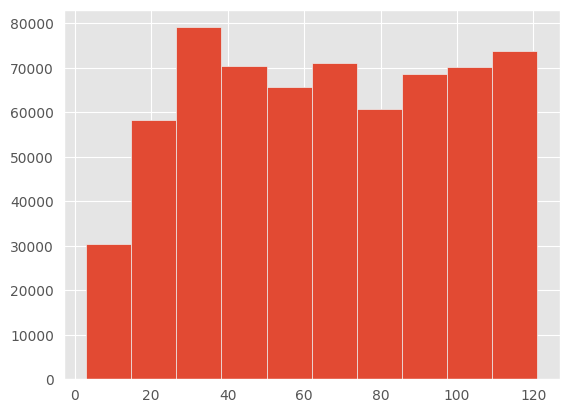

In [ ]:
train_df_copy['Episode_Length_minutes'].hist()

<Axes: >

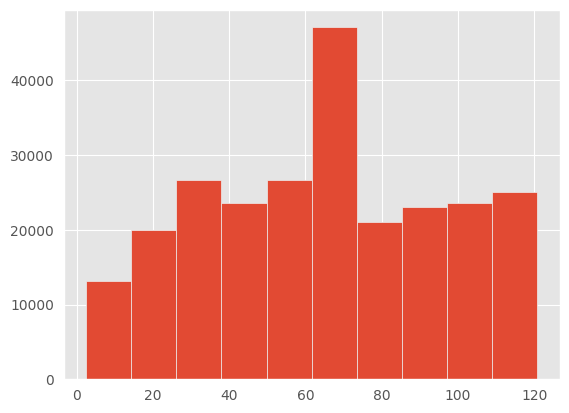

In [ ]:
test_df_copy['Episode_Length_minutes'].hist()

In [ ]:
test_df_copy['Listening_Time_minutes'] = 0

In [ ]:
test_df_copy.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Guest_Popularity_percentage',
       'Number_of_Ads', 'PD_Friday', 'PD_Monday', 'PD_Saturday', 'PD_Sunday',
       'PD_Thursday', 'PD_Tuesday', 'PD_Wednesday', 'PT_Afternoon',
       'PT_Evening', 'PT_Morning', 'PT_Night', 'ES_Negative', 'ES_Neutral',
       'ES_Positive', 'Listening_Time_minutes'],
      dtype='object')

In [ ]:
#ya tenemos el index de donde van a iterar los diferentes modelos ahora para test
for i in index_rf:
  name = combinaciones.loc[i, 'Podcast_Name']
  title = combinaciones.loc[i, 'Episode_Title']
  xtest = test_df_copy[(test_df_copy['Podcast_Name'] == name) & (test_df_copy['Episode_Title'] == title)]
  xtest_model = xtest.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes','Guest_Popularity_percentage'],axis=1)
  xtrain = train_df_copy[(train_df_copy['Podcast_Name'] == name) & (train_df_copy['Episode_Title'] == title)]
  xtrain_model = xtrain.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes','Guest_Popularity_percentage'],axis=1)
  ytrain = xtrain['Listening_Time_minutes']
  X_train, X_test, y_train, y_test = train_test_split(xtrain_model, ytrain, test_size=0.2, random_state=28)
  modelrf = RandomForestRegressor()
  modelrf.fit(X_train, y_train)
  y_pred = modelrf.predict(xtest_model)
  #rellenar las predicciones en test_copy
  xtest['Listening_Time_minutes'] = y_pred
  test_df_copy.update(xtest)
for i in index_lgbm:
  name = combinaciones.loc[i, 'Podcast_Name']
  title = combinaciones.loc[i, 'Episode_Title']
  xtest = test_df_copy[(test_df_copy['Podcast_Name'] == name) & (test_df_copy['Episode_Title'] == title)]
  xtest_model = xtest.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes','Guest_Popularity_percentage'],axis=1)
  xtrain = train_df_copy[(train_df_copy['Podcast_Name'] == name) & (train_df_copy['Episode_Title'] == title)]
  xtrain_model = xtrain.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes','Guest_Popularity_percentage'],axis=1)
  ytrain = xtrain['Listening_Time_minutes']
  X_train, X_test, y_train, y_test = train_test_split(xtrain_model, ytrain, test_size=0.2, random_state=28)
  modelgbm = xgb.XGBRegressor()
  modelgbm.fit(X_train, y_train)
  y_pred = modelgbm.predict(xtest_model)
  #rellenar las predicciones en test_copy
  xtest['Listening_Time_minutes'] = y_pred
  test_df_copy.update(xtest)
for i in index_lr:
  name = combinaciones.loc[i, 'Podcast_Name']
  title = combinaciones.loc[i, 'Episode_Title']
  xtest = test_df_copy[(test_df_copy['Podcast_Name'] == name) & (test_df_copy['Episode_Title'] == title)]
  xtest_model = xtest.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes','Guest_Popularity_percentage'],axis=1)
  xtrain = train_df_copy[(train_df_copy['Podcast_Name'] == name) & (train_df_copy['Episode_Title'] == title)]
  xtrain_model = xtrain.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes','Guest_Popularity_percentage'],axis=1)
  ytrain = xtrain['Listening_Time_minutes']
  X_train, X_test, y_train, y_test = train_test_split(xtrain_model, ytrain, test_size=0.2, random_state=28)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(xtest_model)
  #rellenar las predicciones en test_copy
  xtest['Listening_Time_minutes'] = y_pred
  test_df_copy.update(xtest)

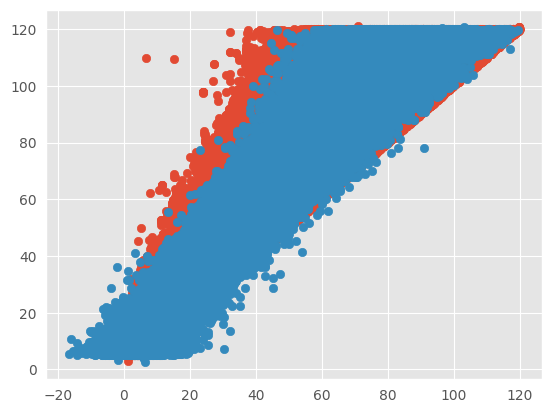

In [ ]:
#comparar scatterplot de listening y episode length de train y test
plt.scatter(train_df_copy['Listening_Time_minutes'], train_df_copy['Episode_Length_minutes'])
plt.scatter(test_df_copy['Listening_Time_minutes'], test_df_copy['Episode_Length_minutes'])
plt.show()

In [ ]:
#ratio de listening y episode test
test_df_copy['Listening_Time_minutes'].sum() / test_df_copy['Episode_Length_minutes'].sum()

np.float64(0.7088037229698408)

In [ ]:
sample_submission_df['Listening_Time_minutes'] = test_df_copy['Listening_Time_minutes']

In [ ]:
sample_submission_df.to_csv('submission8.csv', index=False)